# Oracle Matrix M — with Poker Hand Labels

**Board: Ad Kc 2d** | Pot: 55 | Stack: 180

M is the lookup table at the turn boundary: `CFV = M × opponent_reach`  
- Each **row** = one of your hands (e.g. AsKh, QdJd)
- Each **column** = one opponent hand
- M[i,j] = how much value hand i gains/loses when opponent has hand j

This notebook shows M with actual hand names so you can see what's going on.

In [11]:
import struct, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import OrderedDict

matplotlib.rcParams['figure.figsize'] = (14, 5)
matplotlib.rcParams['figure.dpi'] = 120

In [12]:
# ── Card/Hand encoding (matches the Rust engine exactly) ──

RANKS = '23456789TJQKA'
SUITS = 'cdhs'

def card_to_str(card_id):
    """card_id (0-51) → string like '2c', 'As'"""
    return RANKS[card_id >> 2] + SUITS[card_id & 3]

def str_to_card(s):
    """'As' → card_id 51"""
    return RANKS.index(s[0]) * 4 + SUITS.index(s[1])

def hand_str(c1, c2):
    """Two card IDs → 'AsKh' (higher card first for readability)"""
    return card_to_str(max(c1, c2)) + card_to_str(min(c1, c2))

def hand_category(c1, c2):
    """Classify hand: 'AA', 'AKs', 'AKo' style"""
    r1, s1 = c1 >> 2, c1 & 3
    r2, s2 = c2 >> 2, c2 & 3
    hi, lo = max(r1, r2), min(r1, r2)
    hi_c, lo_c = RANKS[hi], RANKS[lo]
    if r1 == r2:
        return f'{hi_c}{lo_c}'  # pair
    elif s1 == s2:
        return f'{hi_c}{lo_c}s'  # suited
    else:
        return f'{hi_c}{lo_c}o'  # offsuit

def parse_range(range_str, dead_mask):
    """Parse range string → list of (card1, card2) in engine order."""
    weights = {}
    for entry in range_str.split(','):
        entry = entry.strip()
        if ':' in entry:
            hand_part, w = entry.rsplit(':', 1)
            w = float(w.strip())
        else:
            hand_part = entry
            w = 1.0
        hand_part = hand_part.strip()
        if len(hand_part) == 4:
            c1 = str_to_card(hand_part[:2])
            c2 = str_to_card(hand_part[2:])
            lo, hi = min(c1, c2), max(c1, c2)
            weights[(lo, hi)] = w
    
    # Engine order: for c1 in 0..52, for c2 in c1+1..52
    hands = []
    for c1 in range(52):
        for c2 in range(c1 + 1, 52):
            mask = (1 << c1) | (1 << c2)
            if mask & dead_mask:
                continue
            if (c1, c2) in weights and weights[(c1, c2)] > 0:
                hands.append((c1, c2))
    return hands

# Load config
with open('../config/A-oracle.json') as f:
    config = json.load(f)

# Board: AdKc2d
board_cards = [str_to_card('Ad'), str_to_card('Kc'), str_to_card('2d')]
dead_mask = sum(1 << c for c in board_cards)
print(f"Board: {' '.join(card_to_str(c) for c in board_cards)} (dead mask: {dead_mask:#x})")

# Build hand lists
oop_hands = parse_range(config['ranges']['oop'], dead_mask)
ip_hands = parse_range(config['ranges']['ip'], dead_mask)

oop_labels = [hand_str(c1, c2) for c1, c2 in oop_hands]
ip_labels = [hand_str(c1, c2) for c1, c2 in ip_hands]

oop_cats = [hand_category(c1, c2) for c1, c2 in oop_hands]
ip_cats = [hand_category(c1, c2) for c1, c2 in ip_hands]

print(f"OOP: {len(oop_hands)} hands, IP: {len(ip_hands)} hands")
print()
print(f"OOP first 10: {oop_labels[:10]}")
print(f"OOP last 10:  {oop_labels[-10:]}")
print()
print(f"IP first 10:  {ip_labels[:10]}")
print(f"IP last 10:   {ip_labels[-10:]}")

Board: Ad Kc 2d (dead mask: 0x2100000000002)
OOP: 896 hands, IP: 499 hands

OOP first 10: ['3c2c', '4c2c', '5c2c', '5d2c', '5h2c', '5s2c', '6c2c', '7c2c', '8c2c', '9c2c']
OOP last 10:  ['KsQc', 'KdQd', 'KhQd', 'KsQd', 'KdQh', 'KhQh', 'KsQh', 'KdQs', 'KhQs', 'KsQs']

IP first 10:  ['Ah2c', 'As2c', 'Ac2h', 'As2h', 'Ac2s', 'Ah2s', 'Ah3c', 'As3c', 'Kd3d', 'Ac3d']
IP last 10:   ['KsKh', 'AcKh', 'AhKh', 'AsKh', 'AcKs', 'AhKs', 'AsKs', 'AhAc', 'AsAc', 'AsAh']


## Load Oracle

The oracle file contains precomputed M matrices for each boundary pot amount.

In [13]:
def load_oracle(path):
    with open(path, 'rb') as f:
        magic = f.read(8)
        assert magic == b'TORACLE\0', f'Bad magic: {magic}'
        num_oop = struct.unpack('<I', f.read(4))[0]
        num_ip = struct.unpack('<I', f.read(4))[0]
        num_amounts = struct.unpack('<I', f.read(4))[0]
        matrices = {}
        for _ in range(num_amounts):
            amount = struct.unpack('<i', f.read(4))[0]
            oop = np.frombuffer(f.read(num_oop * num_ip * 4), dtype=np.float32).reshape(num_oop, num_ip)
            ip = np.frombuffer(f.read(num_ip * num_oop * 4), dtype=np.float32).reshape(num_ip, num_oop)
            matrices[amount] = {'oop': oop.copy(), 'ip': ip.copy()}
    return num_oop, num_ip, matrices

ORACLE_PATH = '../data/oracles/A-oracle.oracle'
num_oop, num_ip, matrices = load_oracle(ORACLE_PATH)
amounts = sorted(matrices.keys())

assert num_oop == len(oop_hands), f"Mismatch: oracle has {num_oop} OOP but we parsed {len(oop_hands)}"
assert num_ip == len(ip_hands), f"Mismatch: oracle has {num_ip} IP but we parsed {len(ip_hands)}"

print(f'OOP hands: {num_oop}, IP hands: {num_ip}')
print(f'Matrix shape: {num_oop} × {num_ip} = {num_oop * num_ip:,} entries')
print(f'Boundary amounts ({len(amounts)}): {amounts}')
print(f'Hand labels verified ✓')

OOP hands: 896, IP hands: 499
Matrix shape: 896 × 499 = 447,104 entries
Boundary amounts (10): [0, 18, 36, 55, 64, 83, 100, 109, 138, 180]
Hand labels verified ✓


## 1. Heatmap with Hand Labels (amount=55, starting pot)

Red = OOP hand gains value when IP has that hand  
Blue = OOP hand loses value when IP has that hand  
(Board: Ad Kc 2d)

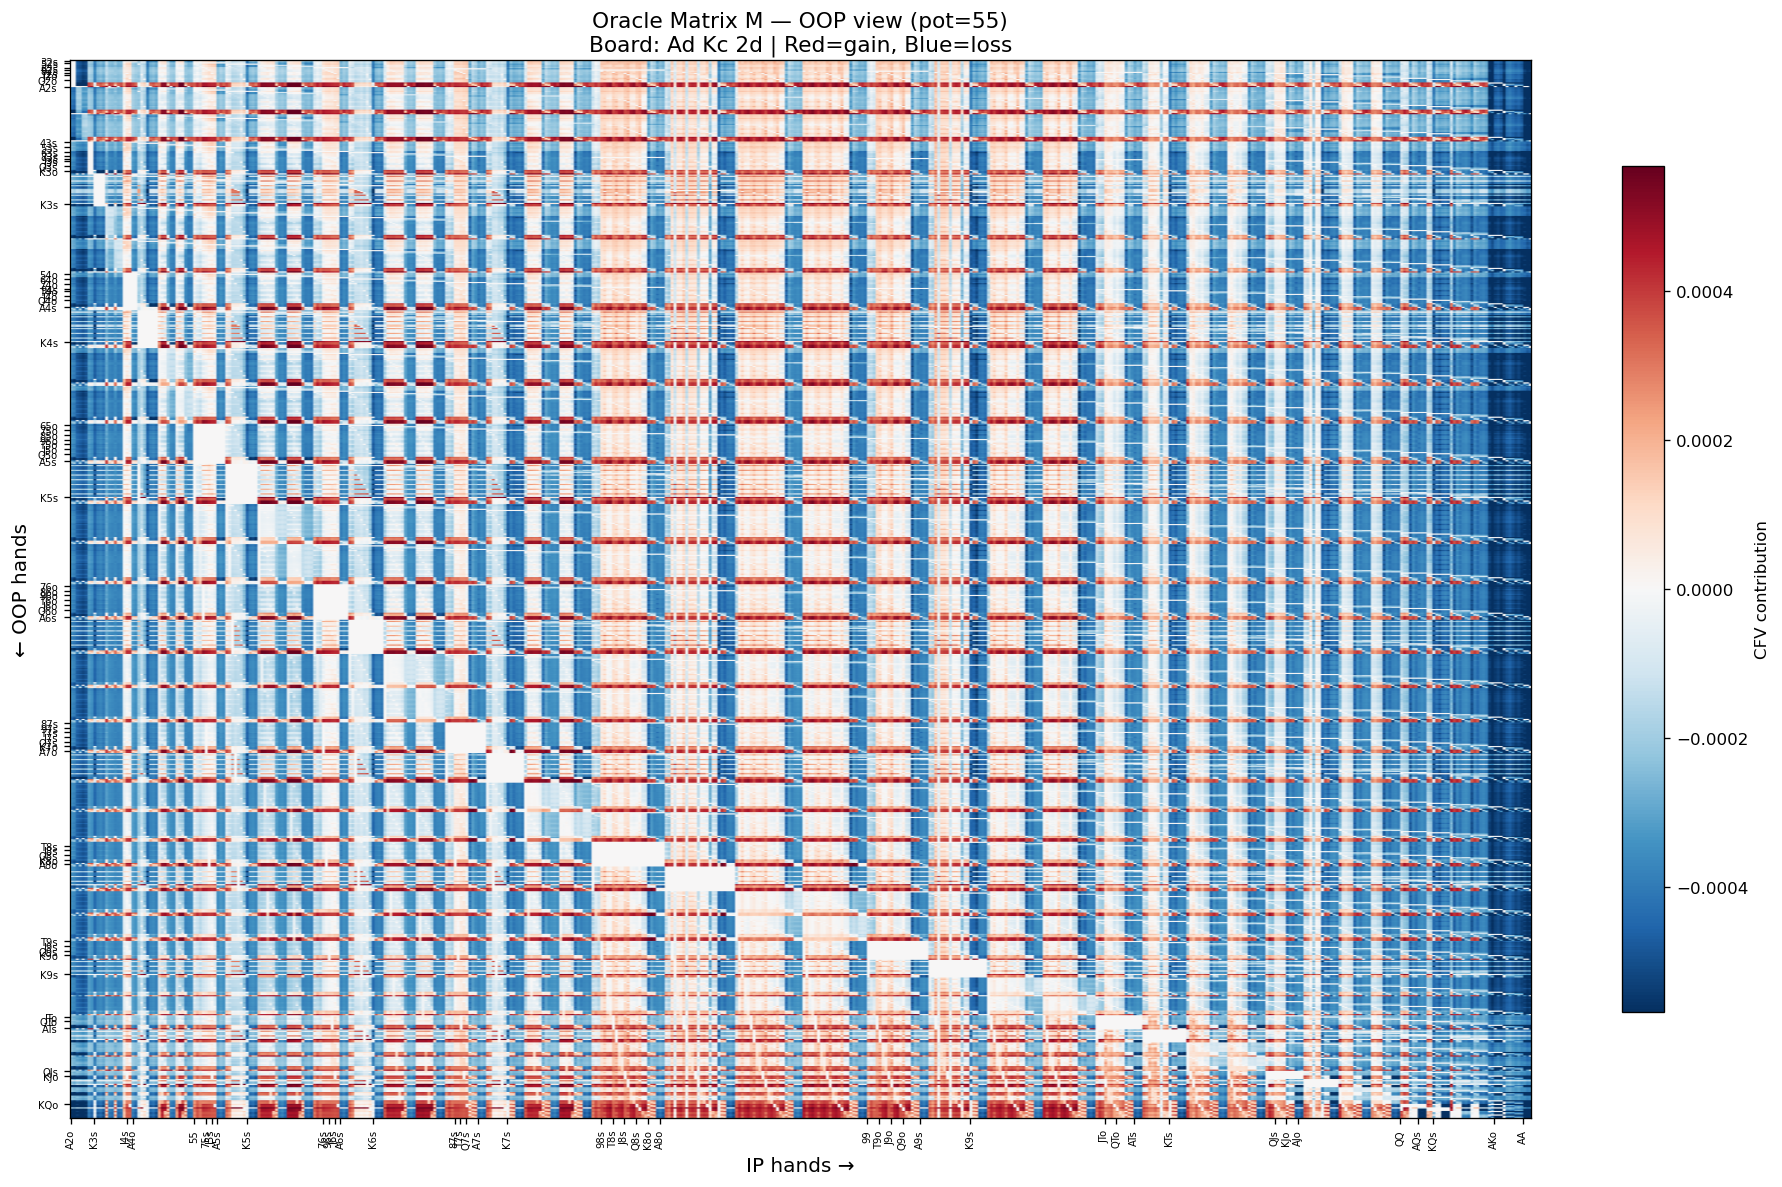

In [14]:
def find_hand_boundaries(cats):
    """Find where each hand category starts in the ordered list."""
    boundaries = OrderedDict()
    for i, cat in enumerate(cats):
        if cat not in boundaries:
            boundaries[cat] = i
    return boundaries

def add_hand_ticks(ax, labels, cats, axis='x', max_ticks=40):
    """Add hand category labels at boundary positions."""
    boundaries = find_hand_boundaries(cats)
    # Pick evenly spaced categories
    all_cats = list(boundaries.keys())
    if len(all_cats) > max_ticks:
        step = len(all_cats) // max_ticks
        selected = all_cats[::step]
    else:
        selected = all_cats
    
    positions = [boundaries[c] for c in selected]
    
    if axis == 'x':
        ax.set_xticks(positions)
        ax.set_xticklabels(selected, rotation=90, fontsize=6)
    else:
        ax.set_yticks(positions)
        ax.set_yticklabels(selected, fontsize=6)

# Use starting pot amount
amount = 55
M = matrices[amount]['oop']

fig, ax = plt.subplots(figsize=(16, 10))
vmax = np.percentile(np.abs(M), 99)
im = ax.imshow(M, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

add_hand_ticks(ax, oop_labels, oop_cats, axis='y', max_ticks=50)
add_hand_ticks(ax, ip_labels, ip_cats, axis='x', max_ticks=40)

ax.set_xlabel('IP hands →', fontsize=12)
ax.set_ylabel('← OOP hands', fontsize=12)
ax.set_title(f'Oracle Matrix M — OOP view (pot={amount})\nBoard: Ad Kc 2d | Red=gain, Blue=loss', fontsize=13)
plt.colorbar(im, ax=ax, label='CFV contribution', shrink=0.8)
plt.tight_layout()
plt.show()

## 2. Zoomed View — Top Pairs & Broadway vs IP range

Let's zoom into a small region so we can read every hand name.

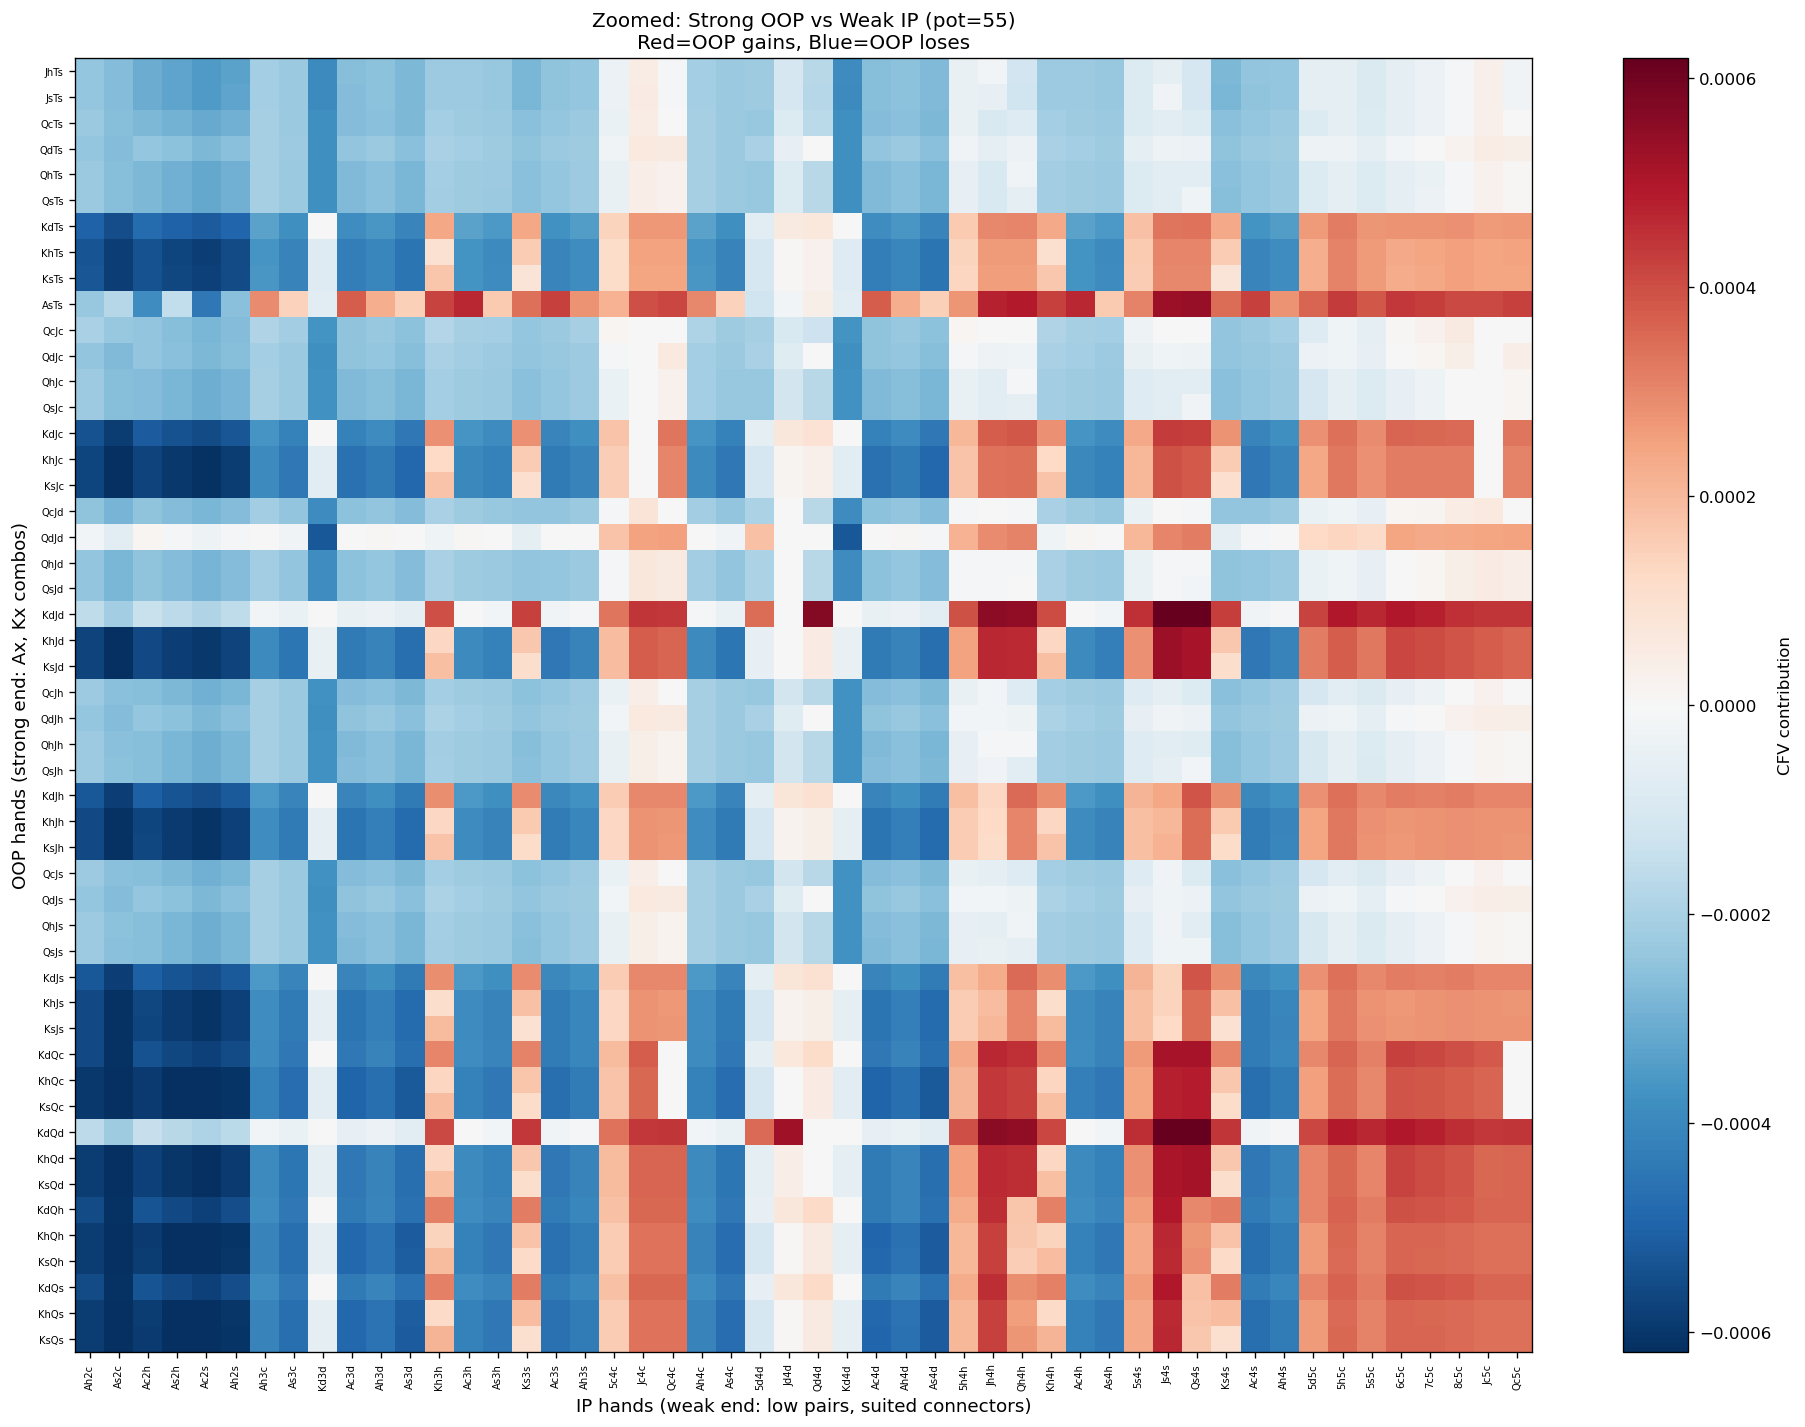

In [15]:
# Zoom into the last 50 OOP hands (strong hands: Ax, Kx, premium) vs first 50 IP hands (weak)
amount = 55
M = matrices[amount]['oop']

# Strong OOP hands (end of list = high cards)
oop_slice = slice(-50, None)
# Weak IP hands (start of list = low cards)  
ip_slice = slice(0, 50)

M_zoom = M[oop_slice, ip_slice]

fig, ax = plt.subplots(figsize=(16, 12))
vmax = np.percentile(np.abs(M_zoom), 99)
im = ax.imshow(M_zoom, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

# Full hand labels for zoomed view
ax.set_xticks(range(50))
ax.set_xticklabels(ip_labels[:50], rotation=90, fontsize=6)
ax.set_yticks(range(50))
ax.set_yticklabels(oop_labels[-50:], fontsize=6)

ax.set_xlabel('IP hands (weak end: low pairs, suited connectors)', fontsize=11)
ax.set_ylabel('OOP hands (strong end: Ax, Kx combos)', fontsize=11)
ax.set_title(f'Zoomed: Strong OOP vs Weak IP (pot={amount})\nRed=OOP gains, Blue=OOP loses', fontsize=12)
plt.colorbar(im, ax=ax, label='CFV contribution')
plt.tight_layout()
plt.show()

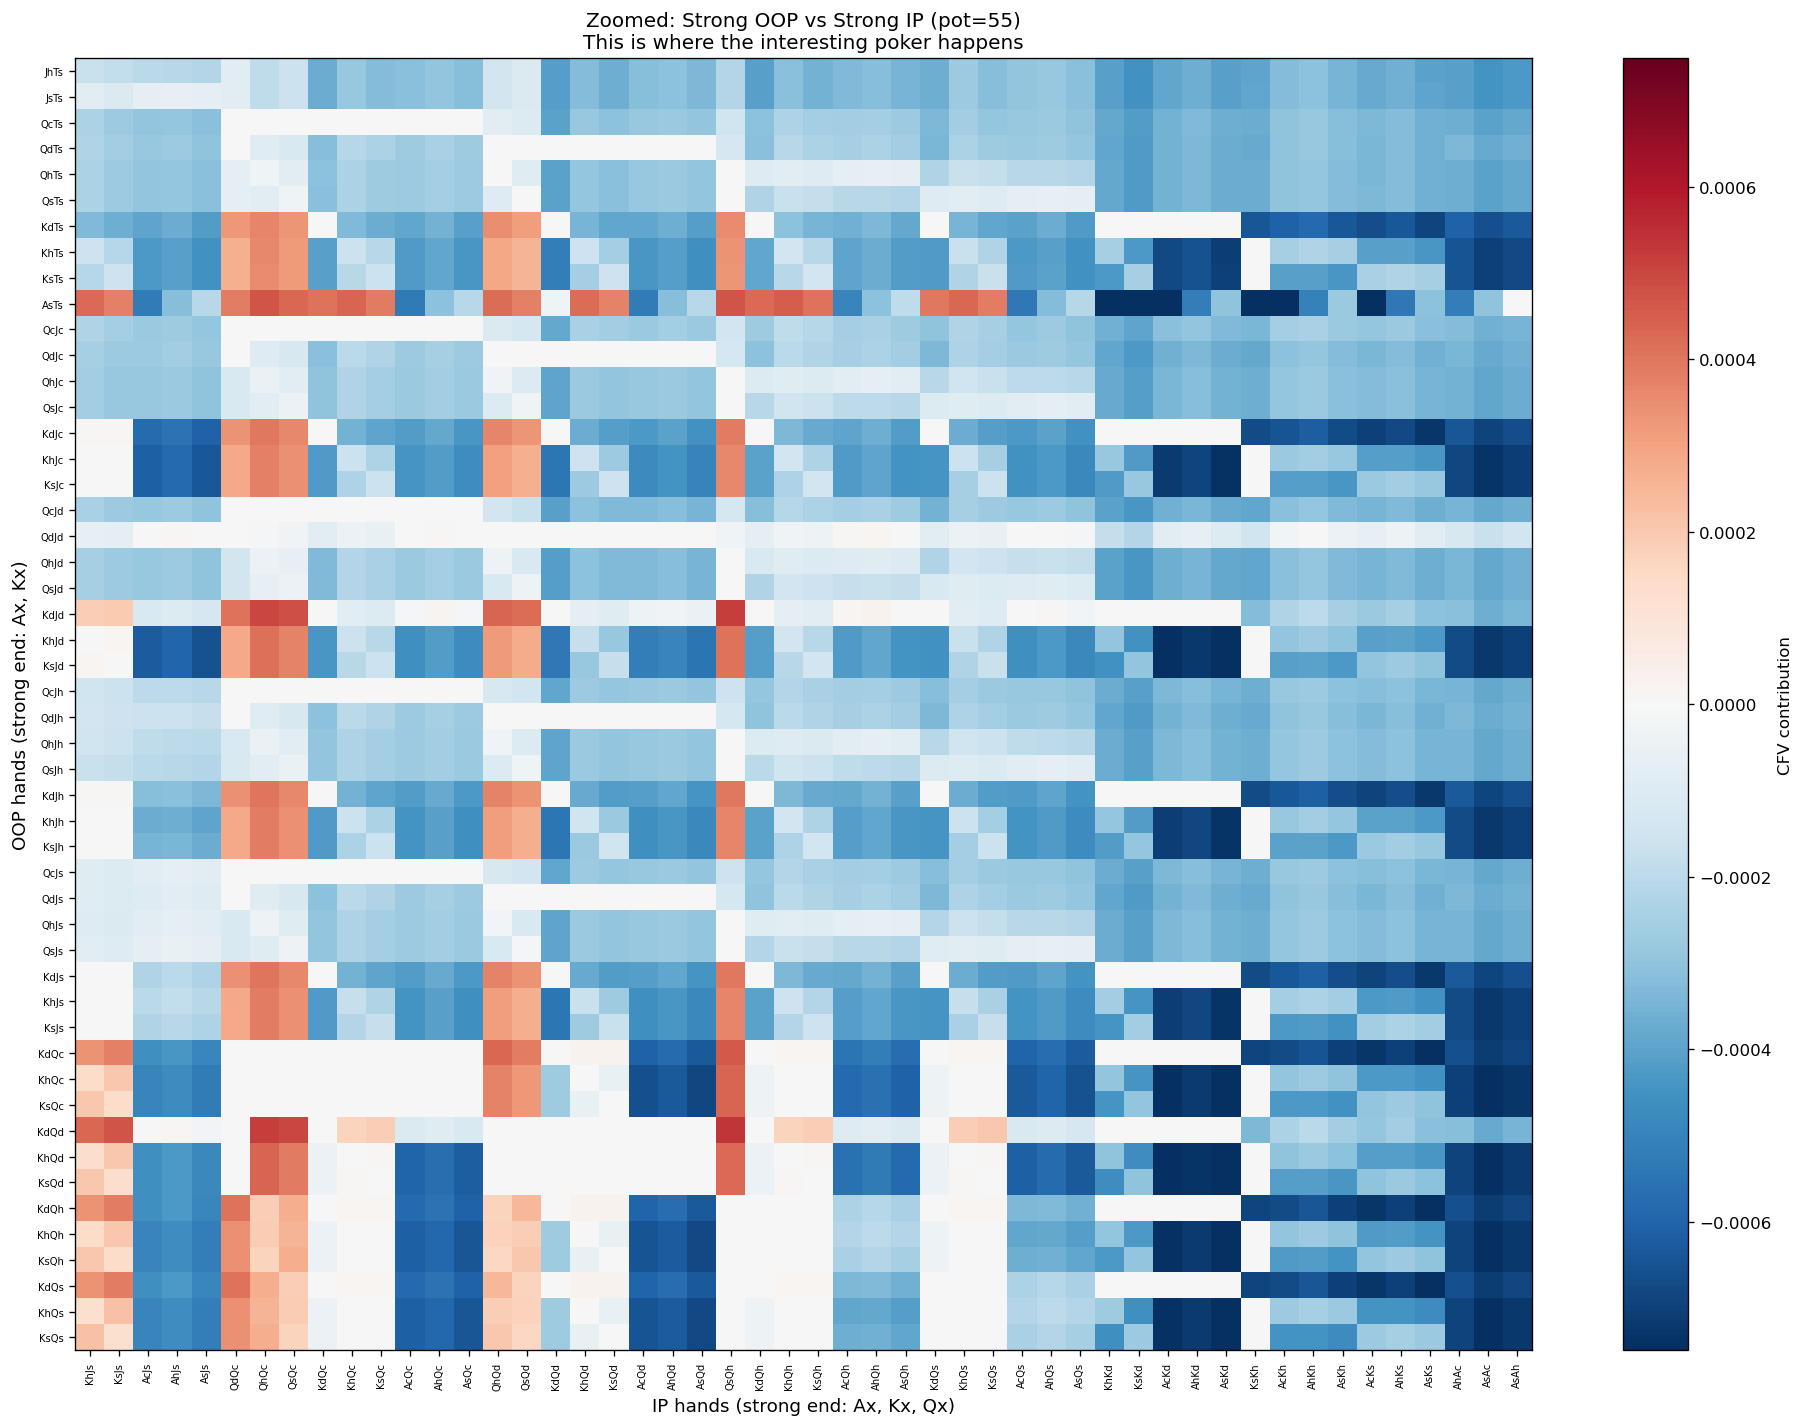

In [16]:
# Zoom: Strong OOP vs Strong IP
oop_slice = slice(-50, None)
ip_slice = slice(-50, None)

M_zoom = M[oop_slice, ip_slice]

fig, ax = plt.subplots(figsize=(16, 12))
vmax = np.percentile(np.abs(M_zoom), 99)
im = ax.imshow(M_zoom, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(50))
ax.set_xticklabels(ip_labels[-50:], rotation=90, fontsize=6)
ax.set_yticks(range(50))
ax.set_yticklabels(oop_labels[-50:], fontsize=6)

ax.set_xlabel('IP hands (strong end: Ax, Kx, Qx)', fontsize=11)
ax.set_ylabel('OOP hands (strong end: Ax, Kx)', fontsize=11)
ax.set_title(f'Zoomed: Strong OOP vs Strong IP (pot={amount})\nThis is where the interesting poker happens', fontsize=12)
plt.colorbar(im, ax=ax, label='CFV contribution')
plt.tight_layout()
plt.show()

## 3. Which hands win/lose the most?

Average M value per hand = how much value that hand gains/loses on average against the opponent range.

In [17]:
amount = 55
M = matrices[amount]['oop']

# Average value per OOP hand (average across all IP hands)
oop_avg = M.mean(axis=1)

# Top 20 winners and losers
oop_sorted = np.argsort(oop_avg)

print("=== OOP Hands: Biggest Winners (gain most vs IP range) ===")
print(f"{'Hand':<8} {'Category':<6} {'Avg Value':>10}")
print("-" * 28)
for idx in oop_sorted[-20:][::-1]:
    print(f"{oop_labels[idx]:<8} {oop_cats[idx]:<6} {oop_avg[idx]:>10.6f}")

print()
print("=== OOP Hands: Biggest Losers (lose most vs IP range) ===")
print(f"{'Hand':<8} {'Category':<6} {'Avg Value':>10}")
print("-" * 28)
for idx in oop_sorted[:20]:
    print(f"{oop_labels[idx]:<8} {oop_cats[idx]:<6} {oop_avg[idx]:>10.6f}")

=== OOP Hands: Biggest Winners (gain most vs IP range) ===
Hand     Category  Avg Value
----------------------------
Ac2c     A2s      0.000354
As2s     A2s      0.000346
Ah2h     A2s      0.000346
Kd2h     K2o      0.000334
Kd2s     K2o      0.000334
Kd2c     K2o      0.000333
Kh2h     K2s      0.000305
Ks2s     K2s      0.000305
Ks2h     K2o      0.000305
Kh2s     K2o      0.000305
Kh2c     K2o      0.000305
Ks2c     K2o      0.000305
KdQd     KQs      0.000280
AcTc     ATs      0.000274
KdJd     KJs      0.000273
KdTd     KTs      0.000264
AsTs     ATs      0.000262
AhTh     ATs      0.000262
Kd3d     K3s      0.000255
Kd4d     K4s      0.000253

=== OOP Hands: Biggest Losers (lose most vs IP range) ===
Hand     Category  Avg Value
----------------------------
8h6c     86o     -0.000211
8s6c     86o     -0.000211
8c6h     86o     -0.000210
8c6s     86o     -0.000210
8s3s     83s     -0.000210
8h3h     83s     -0.000210
8s6h     86o     -0.000209
8h6s     86o     -0.000209
8s6s     8

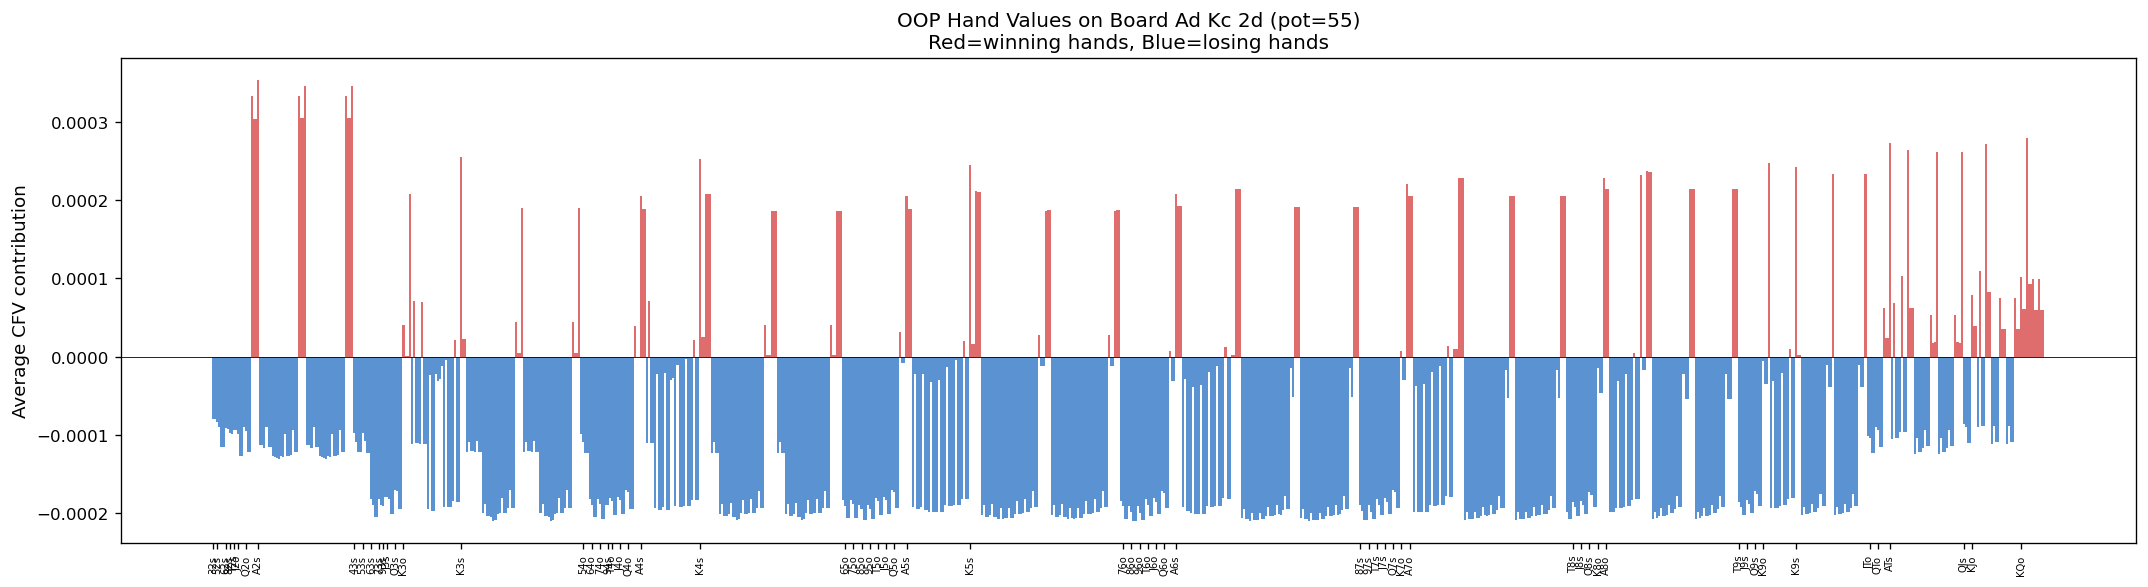

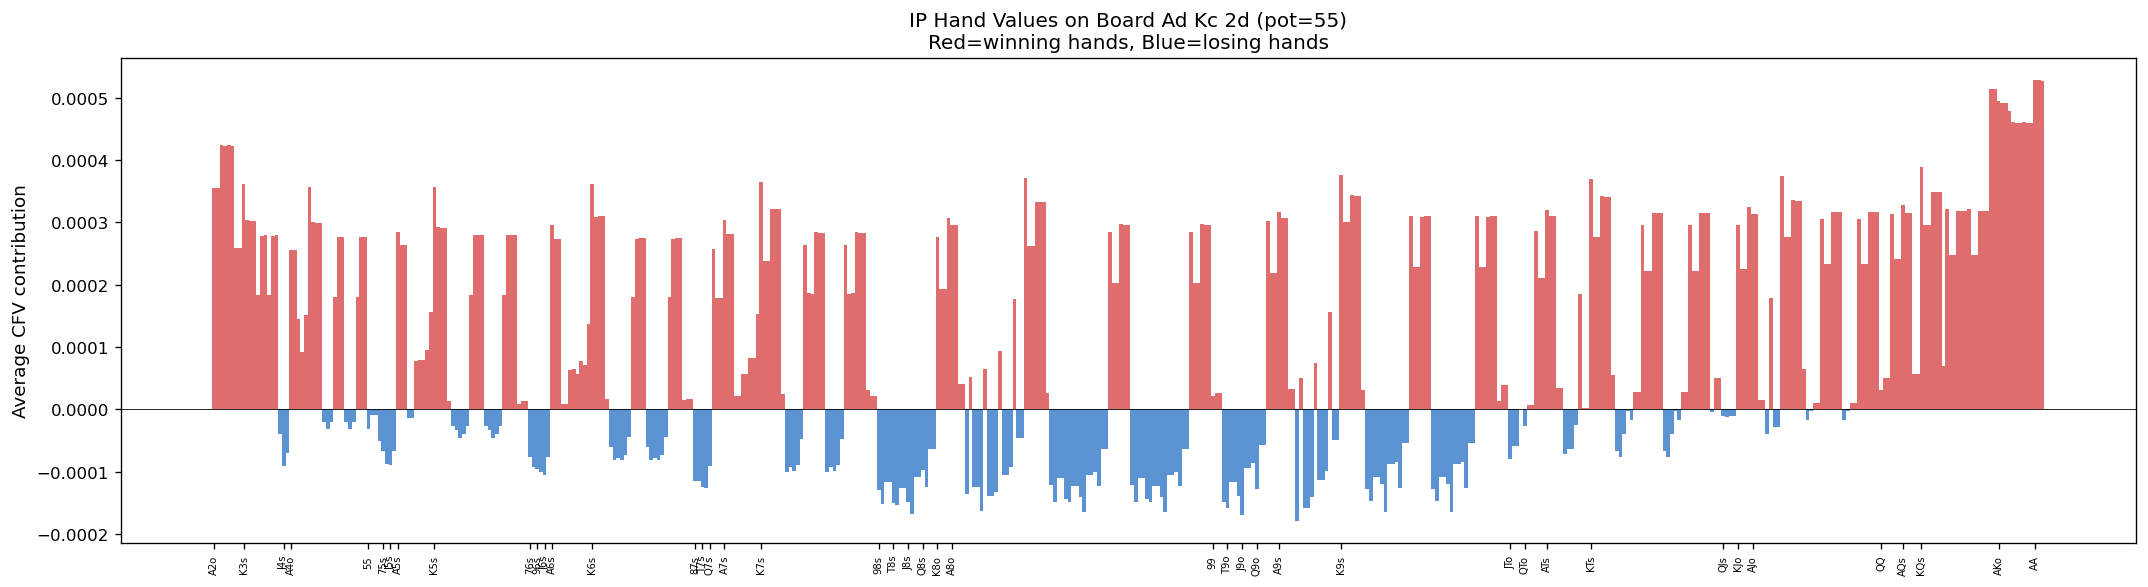

In [18]:
# Bar chart: average value per OOP hand with labels
fig, ax = plt.subplots(figsize=(18, 5))

colors = ['#d32f2f' if v > 0 else '#1565c0' for v in oop_avg]
ax.bar(range(num_oop), oop_avg, width=1.0, color=colors, alpha=0.7)

# Add hand category ticks
add_hand_ticks(ax, oop_labels, oop_cats, axis='x', max_ticks=50)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Average CFV contribution', fontsize=11)
ax.set_title(f'OOP Hand Values on Board Ad Kc 2d (pot={amount})\nRed=winning hands, Blue=losing hands', fontsize=12)
plt.tight_layout()
plt.show()

# Same for IP
ip_avg = matrices[amount]['ip'].mean(axis=1)

fig, ax = plt.subplots(figsize=(18, 5))
colors = ['#d32f2f' if v > 0 else '#1565c0' for v in ip_avg]
ax.bar(range(num_ip), ip_avg, width=1.0, color=colors, alpha=0.7)
add_hand_ticks(ax, ip_labels, ip_cats, axis='x', max_ticks=40)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Average CFV contribution', fontsize=11)
ax.set_title(f'IP Hand Values on Board Ad Kc 2d (pot={amount})\nRed=winning hands, Blue=losing hands', fontsize=12)
plt.tight_layout()
plt.show()

## 4. SVD Patterns — What "low rank" means in poker terms

SVD decomposes M into a sum of simple patterns:  
`M ≈ pattern₁ + pattern₂ + ... + patternₖ`

Each pattern is just: (OOP hand score) × (IP hand score)  
- Pattern 1 ≈ **hand strength** (does your hand beat theirs?)
- Pattern 2 ≈ **draw potential** (flush draws, straight draws)
- Pattern 3+ = more subtle interactions

Only ~50 patterns are needed to reconstruct 99% of M.

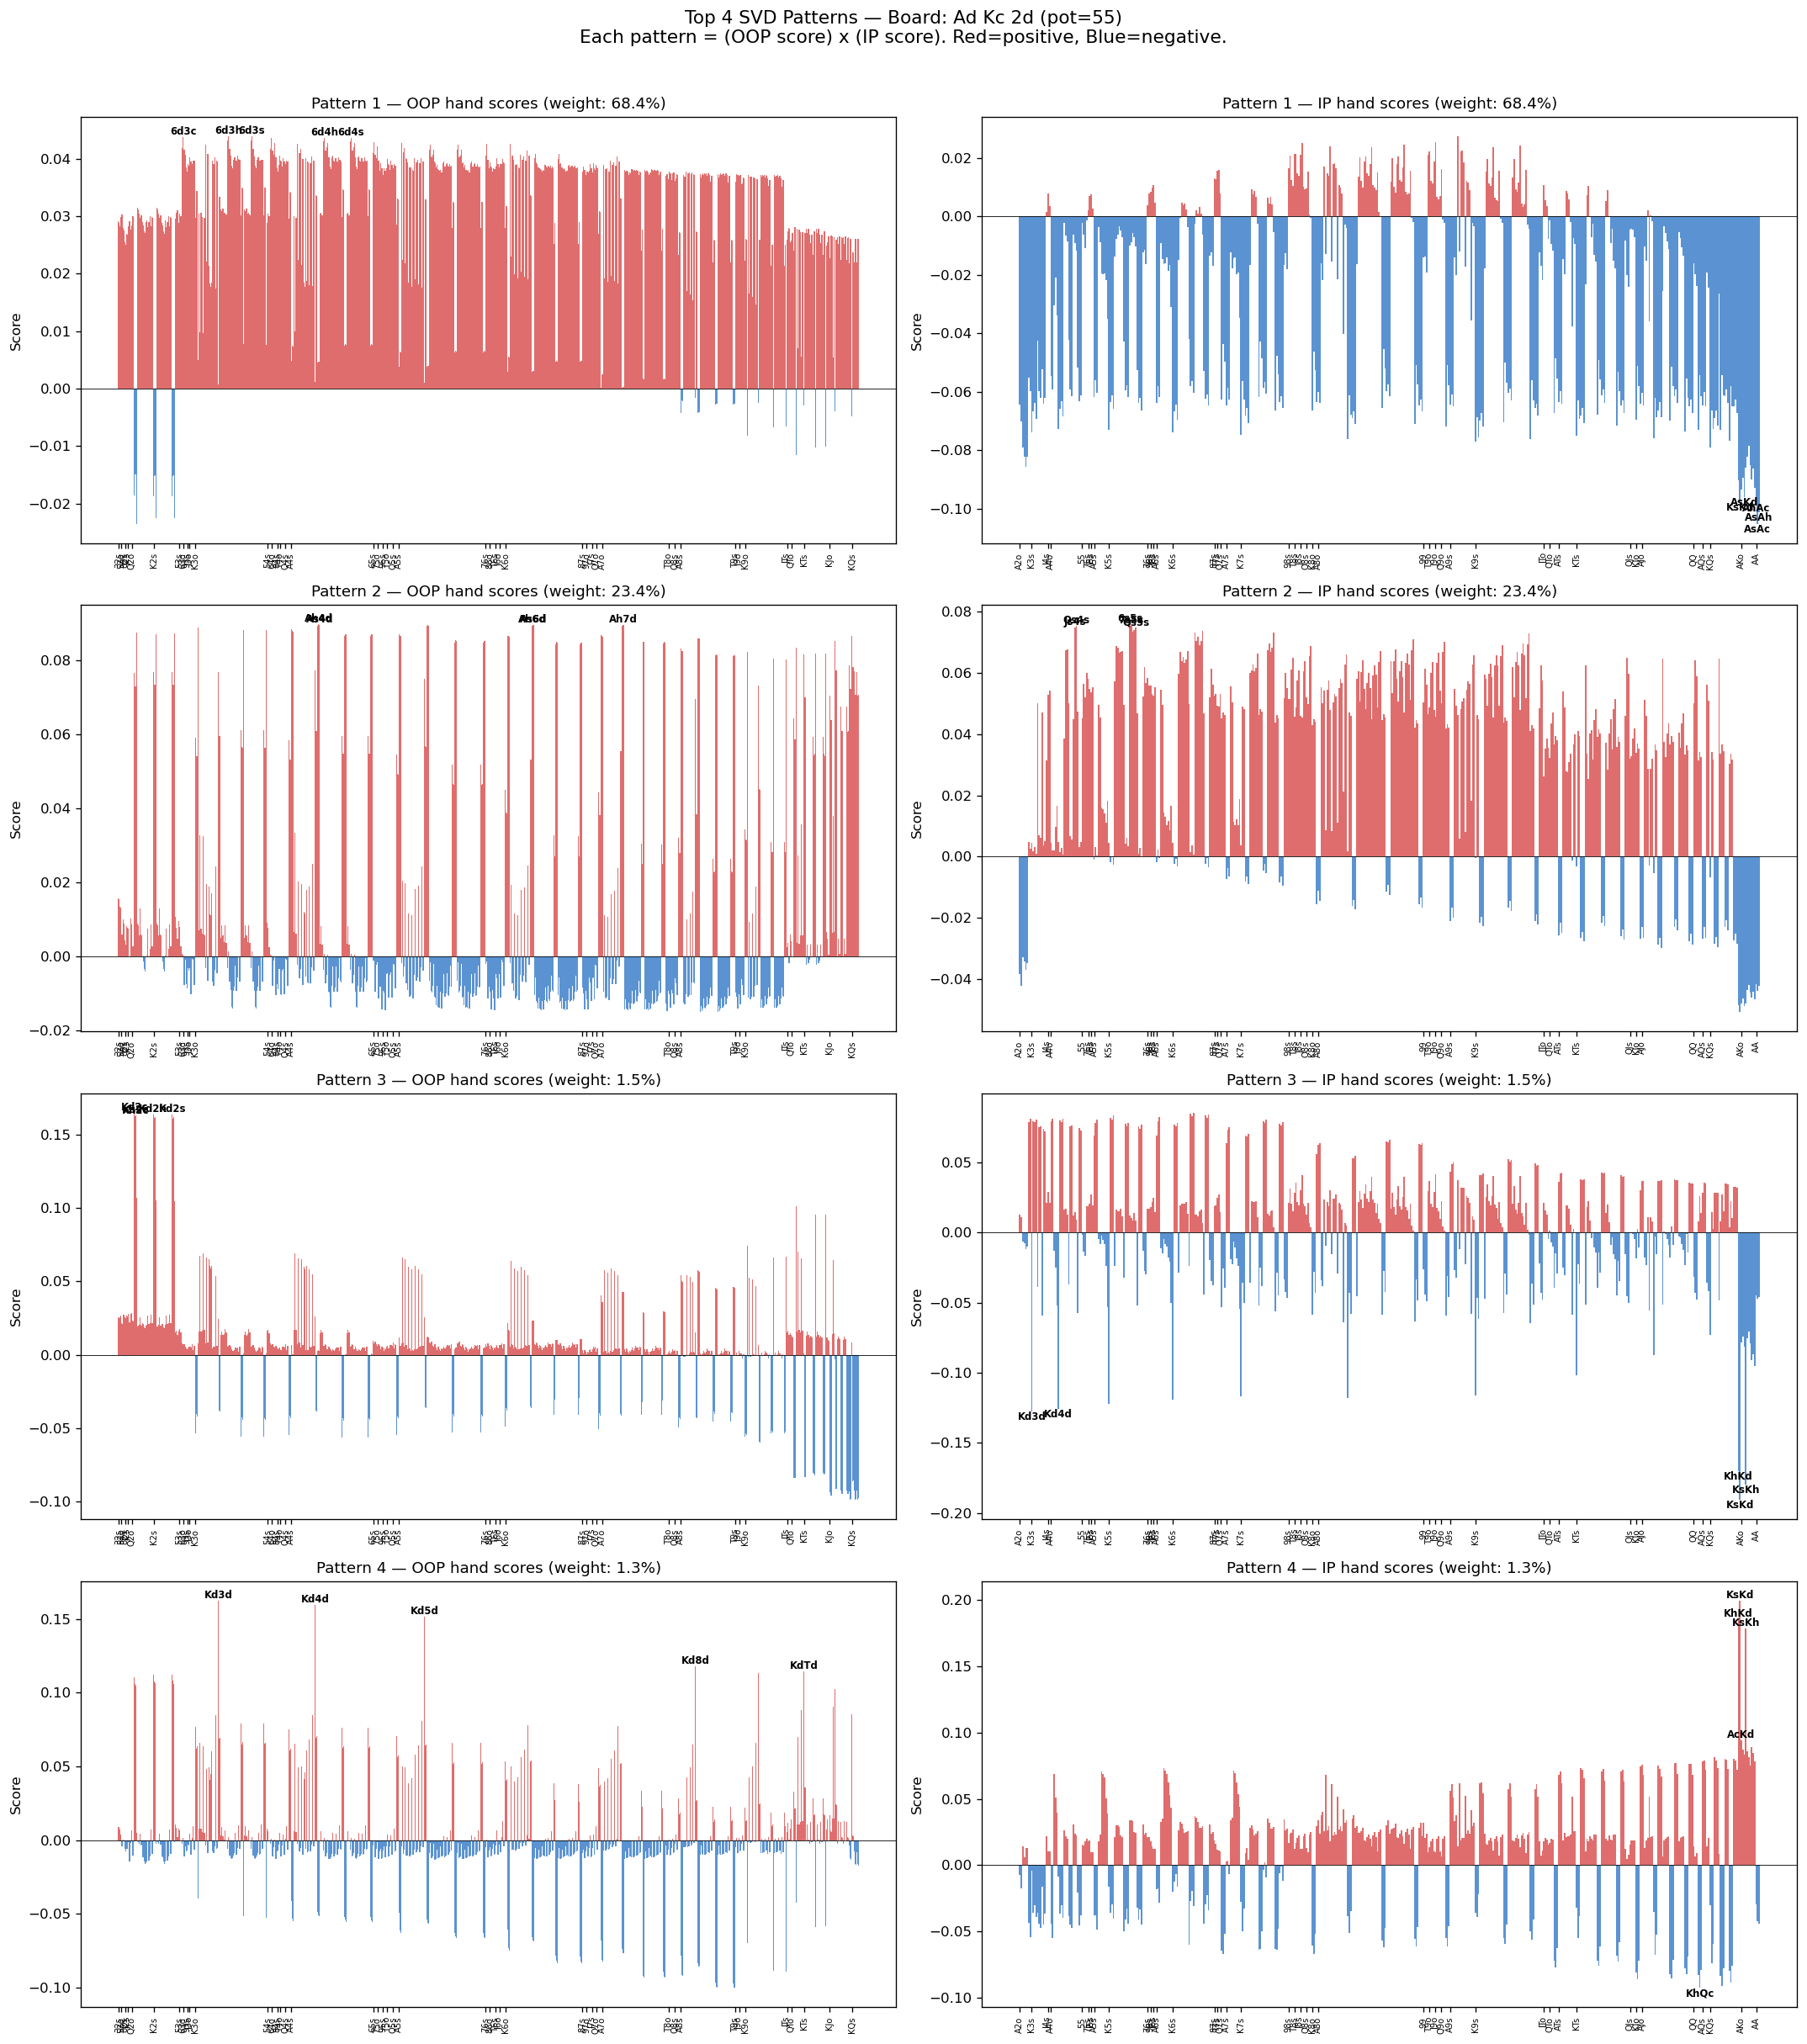

Pattern weights (how much each pattern contributes):
  Pattern 1:  68.4% (cumulative:  68.4%)
  Pattern 2:  23.4% (cumulative:  91.8%)
  Pattern 3:   1.5% (cumulative:  93.3%)
  Pattern 4:   1.3% (cumulative:  94.5%)
  Pattern 5:   0.4% (cumulative:  95.0%)
  Pattern 6:   0.4% (cumulative:  95.3%)
  Pattern 7:   0.3% (cumulative:  95.6%)
  Pattern 8:   0.2% (cumulative:  95.8%)
  Pattern 9:   0.2% (cumulative:  96.0%)
  Pattern 10:   0.2% (cumulative:  96.2%)


In [19]:
# Compute SVD for the starting pot amount
amount = 55
M = matrices[amount]['oop']
U, S, Vt = np.linalg.svd(M, full_matrices=False)

# Show top 4 patterns with hand labels
fig, axes = plt.subplots(4, 2, figsize=(18, 20))

for k in range(4):
    # OOP score for this pattern
    ax = axes[k, 0]
    ax.bar(range(num_oop), U[:, k], width=1.0, 
           color=['#d32f2f' if v > 0 else '#1565c0' for v in U[:, k]], alpha=0.7)
    add_hand_ticks(ax, oop_labels, oop_cats, axis='x', max_ticks=40)
    
    # Annotate top 5 hands
    top5 = np.argsort(np.abs(U[:, k]))[-5:]
    for idx in top5:
        ax.annotate(oop_labels[idx], (idx, U[idx, k]), fontsize=7, 
                    ha='center', va='bottom' if U[idx, k] > 0 else 'top',
                    fontweight='bold')
    
    weight_pct = S[k]**2 / (S**2).sum() * 100
    ax.set_title(f'Pattern {k+1} — OOP hand scores (weight: {weight_pct:.1f}%)', fontsize=11)
    ax.set_ylabel('Score')
    ax.axhline(0, color='black', linewidth=0.5)

    # IP score for this pattern
    ax = axes[k, 1]
    ax.bar(range(num_ip), Vt[k, :], width=1.0,
           color=['#d32f2f' if v > 0 else '#1565c0' for v in Vt[k, :]], alpha=0.7)
    add_hand_ticks(ax, ip_labels, ip_cats, axis='x', max_ticks=35)
    
    top5 = np.argsort(np.abs(Vt[k, :]))[-5:]
    for idx in top5:
        ax.annotate(ip_labels[idx], (idx, Vt[k, idx]), fontsize=7,
                    ha='center', va='bottom' if Vt[k, idx] > 0 else 'top',
                    fontweight='bold')
    
    ax.set_title(f'Pattern {k+1} — IP hand scores (weight: {weight_pct:.1f}%)', fontsize=11)
    ax.set_ylabel('Score')
    ax.axhline(0, color='black', linewidth=0.5)

fig.suptitle(f'Top 4 SVD Patterns — Board: Ad Kc 2d (pot={amount})\n'
             'Each pattern = (OOP score) x (IP score). Red=positive, Blue=negative.', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Print pattern weights
print("Pattern weights (how much each pattern contributes):")
total_energy = (S**2).sum()
cum_energy = 0.0
for k in range(10):
    pct = S[k]**2 / total_energy * 100
    cum_energy += pct
    print(f"  Pattern {k+1}: {pct:5.1f}% (cumulative: {cum_energy:5.1f}%)")

## 5. Top Hands per Pattern

Which specific hands load highest on each SVD pattern?

In [20]:
for k in range(6):
    weight_pct = S[k]**2 / (S**2).sum() * 100
    print(f"═══ Pattern {k+1} ({weight_pct:.1f}% of total) ═══")
    
    # Top OOP hands (positive and negative)
    oop_scores = U[:, k]
    oop_pos = np.argsort(oop_scores)[-10:][::-1]
    oop_neg = np.argsort(oop_scores)[:10]
    
    print(f"  OOP positive (high score):")
    for idx in oop_pos:
        print(f"    {oop_labels[idx]:<8} ({oop_cats[idx]:<5})  score={oop_scores[idx]:+.4f}")
    print(f"  OOP negative (low score):")
    for idx in oop_neg:
        print(f"    {oop_labels[idx]:<8} ({oop_cats[idx]:<5})  score={oop_scores[idx]:+.4f}")
    
    # Top IP hands
    ip_scores = Vt[k, :]
    ip_pos = np.argsort(ip_scores)[-10:][::-1]
    ip_neg = np.argsort(ip_scores)[:10]
    
    print(f"  IP positive (high score):")
    for idx in ip_pos:
        print(f"    {ip_labels[idx]:<8} ({ip_cats[idx]:<5})  score={ip_scores[idx]:+.4f}")
    print(f"  IP negative (low score):")
    for idx in ip_neg:
        print(f"    {ip_labels[idx]:<8} ({ip_cats[idx]:<5})  score={ip_scores[idx]:+.4f}")
    print()

═══ Pattern 1 (68.4% of total) ═══
  OOP positive (high score):
    6d3h     (63o  )  score=+0.0439
    6d3s     (63o  )  score=+0.0439
    6d3c     (63o  )  score=+0.0437
    6d4h     (64o  )  score=+0.0436
    6d4s     (64o  )  score=+0.0436
    6d4c     (64o  )  score=+0.0436
    6c3h     (63o  )  score=+0.0432
    6c3s     (63o  )  score=+0.0432
    6c4h     (64o  )  score=+0.0430
    6c4s     (64o  )  score=+0.0430
  OOP negative (low score):
    Ac2c     (A2s  )  score=-0.0235
    Ah2h     (A2s  )  score=-0.0225
    As2s     (A2s  )  score=-0.0225
    Kd2s     (K2o  )  score=-0.0187
    Kd2h     (K2o  )  score=-0.0187
    Kd2c     (K2o  )  score=-0.0186
    Kh2s     (K2o  )  score=-0.0152
    Kh2h     (K2s  )  score=-0.0151
    Ks2h     (K2o  )  score=-0.0151
    Ks2s     (K2s  )  score=-0.0151
  IP positive (high score):
    Tc9d     (T9o  )  score=+0.0274
    Jd9c     (J9o  )  score=+0.0253
    Jd8c     (J8o  )  score=+0.0250
    Jd8s     (J8o  )  score=+0.0245
    Jd9s     (J9

## 6. How Many Patterns Do We Need?

Rank compression: reconstruct M using only the top-k patterns.  
Lower rank = fewer patterns = faster NN = less accurate.

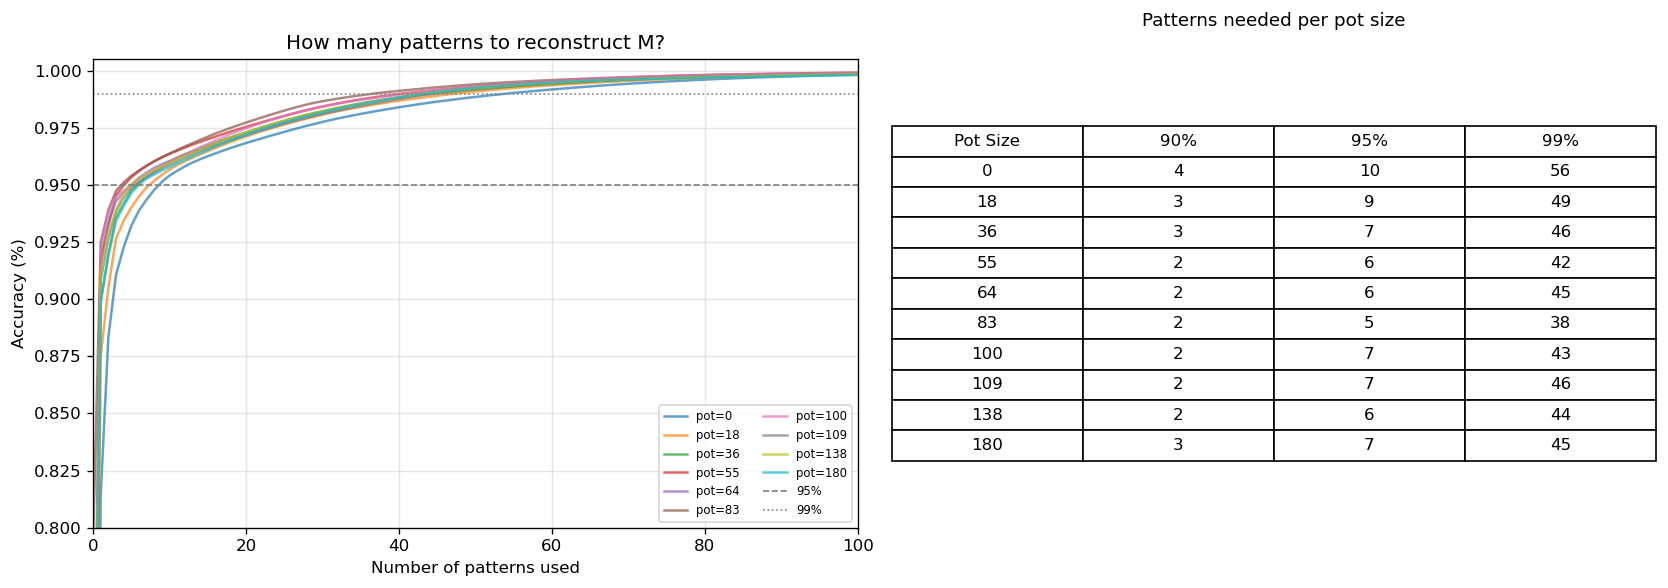


Key takeaway:
  2-4 patterns capture 90% (hand strength dominates)
  5-10 patterns capture 95% (+ draw/blocker effects)
  ~50 patterns capture 99% (+ subtle interactions)
  Full matrix: 447,104 entries -> 50 patterns: 69,750 entries (6.4x compression)


In [21]:
# Compute SVD for all amounts
svd_all = {}
for amt in amounts:
    M_a = matrices[amt]['oop']
    U_a, S_a, Vt_a = np.linalg.svd(M_a, full_matrices=False)
    svd_all[amt] = {'U': U_a, 'S': S_a, 'Vt': Vt_a}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative energy
ax = axes[0]
for amt in amounts:
    S_a = svd_all[amt]['S']
    cum = np.cumsum(S_a**2) / (S_a**2).sum()
    ax.plot(cum, label=f'pot={amt}', alpha=0.7)
ax.axhline(0.95, color='gray', ls='--', lw=1, label='95%')
ax.axhline(0.99, color='gray', ls=':', lw=1, label='99%')
ax.set_xlim(0, 100)
ax.set_ylim(0.8, 1.005)
ax.set_xlabel('Number of patterns used')
ax.set_ylabel('Accuracy (%)')
ax.set_title('How many patterns to reconstruct M?')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Rank table
ax = axes[1]
ax.axis('off')
rows = []
for amt in amounts:
    S_a = svd_all[amt]['S']
    cum = np.cumsum(S_a**2) / (S_a**2).sum()
    r90 = np.searchsorted(cum, 0.90) + 1
    r95 = np.searchsorted(cum, 0.95) + 1
    r99 = np.searchsorted(cum, 0.99) + 1
    rows.append([amt, r90, r95, r99])

table = ax.table(cellText=rows, colLabels=['Pot Size', '90%', '95%', '99%'],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
ax.set_title('Patterns needed per pot size', fontsize=11, pad=20)

plt.tight_layout()
plt.show()

print("\nKey takeaway:")
print("  2-4 patterns capture 90% (hand strength dominates)")
print("  5-10 patterns capture 95% (+ draw/blocker effects)")
print("  ~50 patterns capture 99% (+ subtle interactions)")
print(f"  Full matrix: {num_oop * num_ip:,} entries -> 50 patterns: {50*(num_oop+num_ip):,} entries (6.4x compression)")